In [1]:
#Task 1: Data Understanding
#1.1 Upload and Extract the Dataset
import zipfile

with zipfile.ZipFile("archive (1).zip", "r") as zip_ref:
    zip_ref.extractall("mnist")

In [2]:
#1.2 Verify the Extracted Files
import os

os.listdir("mnist")

['mnist_train.csv', 'mnist_test.csv']

In [3]:
#1.3 Load the Dataset using Pandas
import pandas as pd

train = pd.read_csv("mnist/mnist_train.csv")
test = pd.read_csv("mnist/mnist_test.csv")

In [4]:
#1.4 Display the First Five Records
train.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
#1.5 Identify Input Features and Target Variable
# Separate features and target variable

X = train.drop("label", axis=1)
y = train["label"]

print("Input Features:")
print(X.columns)

print("\nTarget Variable:")
print(y.name)

Input Features:
Index(['1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9', '1x10',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='object', length=784)

Target Variable:
label


In [6]:
#1.6 Display Dataset Dimensions
print("Training Dataset Shape:", train.shape)
print("Testing Dataset Shape:", test.shape)

Training Dataset Shape: (60000, 785)
Testing Dataset Shape: (10000, 785)


In [7]:
#1.7 Display Summary Informatiob
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [8]:
#1.8 Display Statistical Summary
train.describe()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
count,60000.000000,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.0000,60000.0,60000.0,60000.0,60000.0
mean,4.453933,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.200433,0.088867,0.045633,0.019283,0.015117,0.0020,0.0,0.0,0.0,0.0
std,2.889270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.042472,3.956189,2.839845,1.686770,1.678283,0.3466,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.000000,254.000000,62.0000,0.0,0.0,0.0,0.0


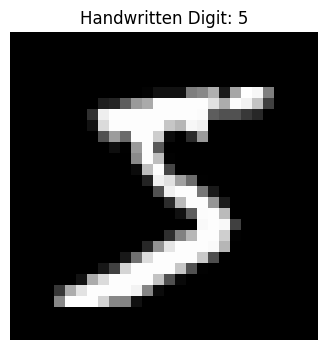

In [9]:
#1.9 Display One Sample Handwritten Digit Using Matplotlib
import matplotlib.pyplot as plt

image = X.iloc[0].values.reshape(28, 28)

plt.figure(figsize=(4,4))
plt.imshow(image, cmap="gray")
plt.title("Handwritten Digit: {}".format(y.iloc[0]))
plt.axis("off")
plt.show()

In [10]:
#Task 2: Data Preprocessing (2 Marks)
#2.1 Check for Missing Values
train.isnull().sum()

,0
label,0
1x1,0
1x2,0
1x3,0
1x4,0
...,...
28x24,0
28x25,0
28x26,0
28x27,0


In [11]:
#2.2 Separate Features and Target Variable
X = train.drop("label", axis=1)
y = train["label"]

In [12]:
#2.3 Normalize Pixel Values to Range 0–1
X = X / 255.0

In [13]:
#2.4 Split the Dataset into 80% Training and 20% Testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [14]:
#2.5 Convert Target Labels into One-Hot Encoding
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (48000, 784)
Testing Data Shape: (12000, 784)


In [15]:
#Task 3: Model Development (3 Marks)
#3.1 Import Required Libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [16]:
#3.2 Build the ANN Model
model = Sequential()

# Input Layer + Hidden Layer 1
model.add(Dense(128, activation='relu', input_shape=(784,)))

# Hidden Layer 2
model.add(Dense(64, activation='relu'))

# Output Layer
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
#3.3 Compile the Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
#3.4 Display Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
#3.5 Train the Model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9156 - loss: 0.2911 - val_accuracy: 0.9524 - val_loss: 0.1578
Epoch 2/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9622 - loss: 0.1244 - val_accuracy: 0.9629 - val_loss: 0.1248
Epoch 3/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9749 - loss: 0.0843 - val_accuracy: 0.9670 - val_loss: 0.1154
Epoch 4/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9803 - loss: 0.0639 - val_accuracy: 0.9654 - val_loss: 0.1140
Epoch 5/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9839 - loss: 0.0490 - val_accuracy: 0.9722 - val_loss: 0.0944
Epoch 6/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9872 - loss: 0.0406 - val_accuracy: 0.9729 - val_loss: 0.0958
Epoch 7/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9908 - loss: 0.0288 - val_accuracy: 0.9720 - val_loss: 0.1036
Epoch 8/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9909 - loss: 0.0287 - 

In [20]:
#3.6 Predict the Handwritten Digits
predictions = model.predict(X_test)

predicted_labels = predictions.argmax(axis=1)

true_labels = y_test.argmax(axis=1)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [21]:
#Task 4: Model Evaluation (2 Marks)
#4.1 Test Accuracy
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9746 - loss: 0.1092
Test Accuracy: 0.9745833277702332


In [22]:
#4.2 Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, predicted_labels)

print("Confusion Matrix")
print(cm)

Confusion Matrix
[[1157    0    2    1    1    1    7    2    3    1]
 [   0 1310    1    2    1    0    5    0    1    2]
 [   2   11 1117   15    3    0    3   12    9    2]
 [   0    0    6 1184    0   12    0    3   11    3]
 [   3    2    2    0 1157    1    3    0    1    7]
 [   3    2    1   14    4 1058    7    3    9    3]
 [   1    2    1    1    2    3 1163    0    4    0]
 [   1    6    6    3    3    0    0 1274    3    3]
 [   1    3    0    7    5    6    7    1 1127    3]
 [   3    2    0    2   18    2    1   13    5 1148]]


In [23]:
#4.3 Classification Report
from sklearn.metrics import classification_report

print(classification_report(true_labels, predicted_labels))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1175
           1       0.98      0.99      0.98      1322
           2       0.98      0.95      0.97      1174
           3       0.96      0.97      0.97      1219
           4       0.97      0.98      0.98      1176
           5       0.98      0.96      0.97      1104
           6       0.97      0.99      0.98      1177
           7       0.97      0.98      0.98      1299
           8       0.96      0.97      0.97      1160
           9       0.98      0.96      0.97      1194

    accuracy                           0.97     12000
   macro avg       0.97      0.97      0.97     12000
weighted avg       0.97      0.97      0.97     12000



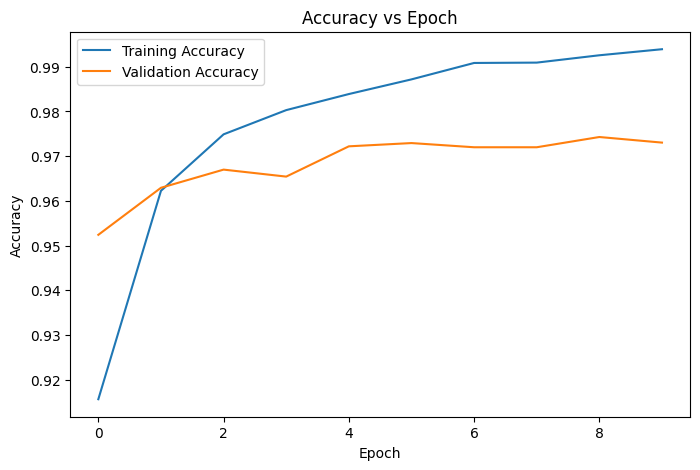

In [24]:
#4.4 Accuracy vs Epoch Graph
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

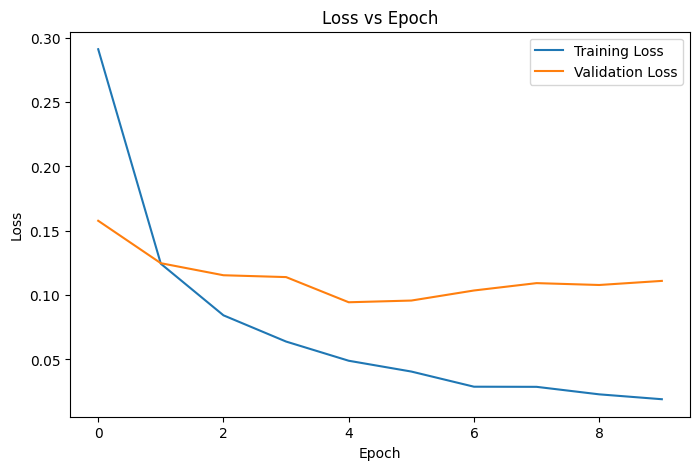

In [25]:
#4.5 Loss vs Epoch Graph
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()